<a href="https://colab.research.google.com/github/AreejSabih/AreejSabih/blob/main/Spam_mail_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📧 Email Spam Classification Using Machine Learning

### Machine Learning Project

**Objective:**  
To develop a machine learning model that automatically classifies emails as either spam or not spam using natural language processing and supervised machine learning techniques.

**Dataset:** Kaggle Spam/Ham Email Dataset

**Algorithms Used:**
- Multinomial Naive Bayes
- Logistic Regression
- Linear Support Vector Machine (SVM)

**Feature Extraction:** TF-IDF

**Final Model:** Logistic Regression

## 1. Importing Libraries

The required Python libraries are imported for data manipulation, visualization, feature extraction, machine learning, and model evaluation.

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from google.colab import files

uploaded = files.upload()


Saving spam_ham_dataset.csv to spam_ham_dataset.csv


## 2. Loading the Dataset

The dataset was obtained from Kaggle and contains labeled email messages. Each email is classified as either `ham` (not spam) or `spam`.

In [2]:
df = pd.read_csv("spam_ham_dataset.csv")

df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


## 3. Exploratory Data Analysis

The dataset is inspected to understand its structure, number of observations, available features, and potential missing values.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5171 non-null   int64 
 1   label       5171 non-null   object
 2   text        5171 non-null   object
 3   label_num   5171 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 161.7+ KB


In [5]:
df.columns

Index(['Unnamed: 0', 'label', 'text', 'label_num'], dtype='object')

In [6]:
df.isnull().sum()

,0
Unnamed: 0,0
label,0
text,0
label_num,0


### Class Distribution

The distribution of spam and non-spam emails is examined to understand the composition of the dataset.

In [7]:
df['label'].value_counts()

,count
label,
ham,3672
spam,1499


In [8]:
df = df.drop(columns=['Unnamed: 0', 'label'])

df.head()

,text,label_num
0,Subject: enron methanol ; meter # : 988291\r\n...,0
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,"Subject: photoshop , windows , office . cheap ...",1
4,Subject: re : indian springs\r\nthis deal is t...,0


In [10]:
df.columns

Index(['text', 'label_num'], dtype='object')

In [11]:
df.head()

,text,label_num
0,Subject: enron methanol ; meter # : 988291\r\n...,0
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,"Subject: photoshop , windows , office . cheap ...",1
4,Subject: re : indian springs\r\nthis deal is t...,0


## 4. Text Preprocessing

Email text contains unnecessary formatting, punctuation, symbols, and inconsistent capitalization. A preprocessing function is used to standardize the text before feature extraction.

The preprocessing steps include:
- Converting text to lowercase
- Removing line breaks
- Removing punctuation and special characters
- Removing unnecessary whitespace

In [13]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\r\n', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['clean_text'] = df['text'].apply(clean_text)

In [14]:
df[['text', 'clean_text', 'label_num']].head()

,text,clean_text,label_num
0,Subject: enron methanol ; meter # : 988291\r\n...,subject enron methanol meter this is a follow ...,0
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",subject hpl nom for january see attached file ...,0
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",subject neon retreat ho ho ho we re around to ...,0
3,"Subject: photoshop , windows , office . cheap ...",subject photoshop windows office cheap main tr...,1
4,Subject: re : indian springs\r\nthis deal is t...,subject re indian springs this deal is to book...,0


## 5. Splitting the Dataset

The dataset is divided into training and testing sets. The training set is used to train the machine learning models, while the testing set is reserved for evaluating their performance on unseen data.

80% of the data is used for training and 20% for testing.

In [16]:
X = df['clean_text']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 6. TF-IDF Feature Extraction

Machine learning algorithms cannot directly process raw text. TF-IDF (Term Frequency-Inverse Document Frequency) is used to convert the email text into numerical features.

TF-IDF gives greater importance to words that are useful for distinguishing between spam and non-spam emails.

In [17]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

In [18]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [19]:
X_test_tfidf = vectorizer.transform(X_test)

In [20]:
print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

Training data shape: (4136, 5000)
Testing data shape: (1035, 5000)


In [21]:
model = MultinomialNB()

In [22]:
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [23]:
y_pred = model.predict(X_test_tfidf)

## 8. Model Evaluation

The models are evaluated using four standard classification metrics:

- **Accuracy:** Percentage of correctly classified emails.
- **Precision:** Proportion of emails predicted as spam that were actually spam.
- **Recall:** Proportion of actual spam emails correctly detected.
- **F1 Score:** Harmonic mean of precision and recall.

In [24]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9507246376811594
Precision: 0.8977635782747604
Recall   : 0.9366666666666666
F1 Score : 0.9168026101141925


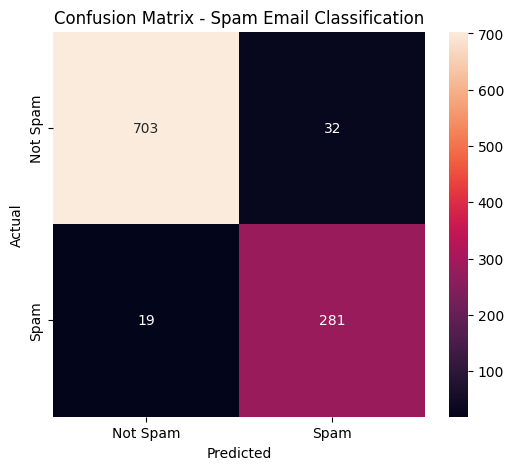

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Not Spam', 'Spam'],
    yticklabels=['Not Spam', 'Spam']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Spam Email Classification')

plt.show()

In [26]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Spam', 'Spam']
))

              precision    recall  f1-score   support

    Not Spam       0.97      0.96      0.96       735
        Spam       0.90      0.94      0.92       300

    accuracy                           0.95      1035
   macro avg       0.94      0.95      0.94      1035
weighted avg       0.95      0.95      0.95      1035



In [27]:
def predict_spam(message):
    cleaned = clean_text(message)
    message_tfidf = vectorizer.transform([cleaned])
    prediction = model.predict(message_tfidf)[0]

    if prediction == 1:
        return "🚨 SPAM"
    else:
        return "✅ NOT SPAM"

In [28]:
print(predict_spam(
    "Congratulations! You have won $1,000. Click here to claim your prize now!"
))

🚨 SPAM


In [29]:
print(predict_spam(
    "Hi, are we still meeting tomorrow at 5 pm? Please let me know."
))

✅ NOT SPAM


In [30]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

In [31]:
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression Results
---------------------------
Accuracy : 0.9845410628019323
Precision: 0.9671052631578947
Recall   : 0.98
F1 Score : 0.9735099337748344


In [32]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

In [33]:
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

print("Linear SVM Results")
print("-----------------")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

Linear SVM Results
-----------------
Accuracy : 0.9835748792270531
Precision: 0.9732441471571907
Recall   : 0.97
F1 Score : 0.9716193656093489


In [34]:
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression Results
---------------------------
Accuracy : 0.9845410628019323
Precision: 0.9671052631578947
Recall   : 0.98
F1 Score : 0.9735099337748344


## 9. Model Comparison

The performance of all three machine learning algorithms is compared using accuracy, precision, recall, and F1-score.

In [35]:
results = pd.DataFrame({
    'Model': [
        'Multinomial Naive Bayes',
        'Logistic Regression',
        'Linear SVM'
    ],
    'Accuracy': [
        accuracy,
        lr_accuracy,
        svm_accuracy
    ],
    'Precision': [
        precision,
        lr_precision,
        svm_precision
    ],
    'Recall': [
        recall,
        lr_recall,
        svm_recall
    ],
    'F1 Score': [
        f1,
        lr_f1,
        svm_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.950725,0.897764,0.936667,0.916803
1,Logistic Regression,0.984541,0.967105,0.980000,0.973510
2,Linear SVM,0.983575,0.973244,0.970000,0.971619


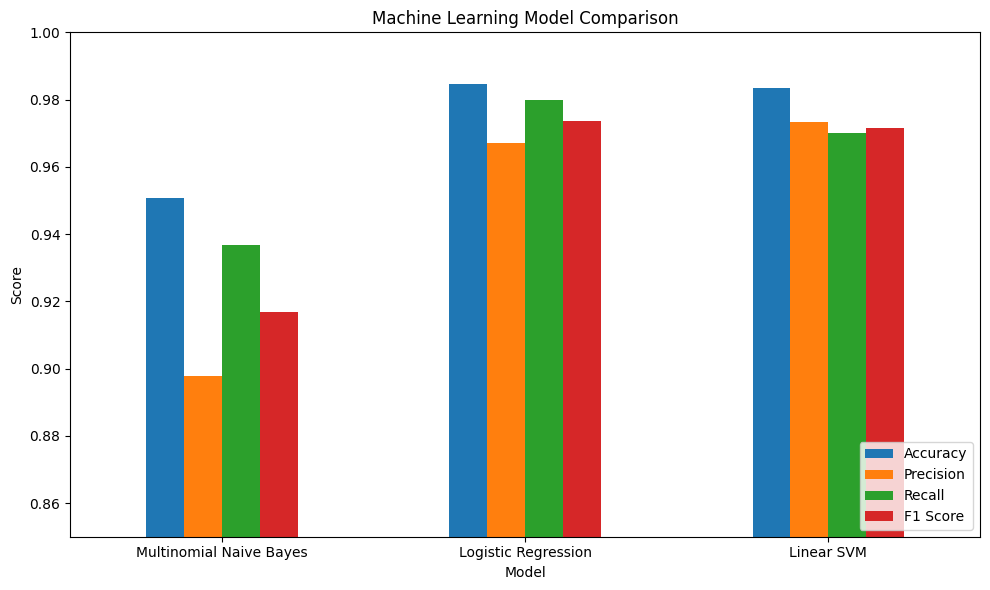

In [36]:
results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Machine Learning Model Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0.85, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 10. Confusion Matrix

A confusion matrix is used to examine the types of correct and incorrect predictions made by the final Logistic Regression model.

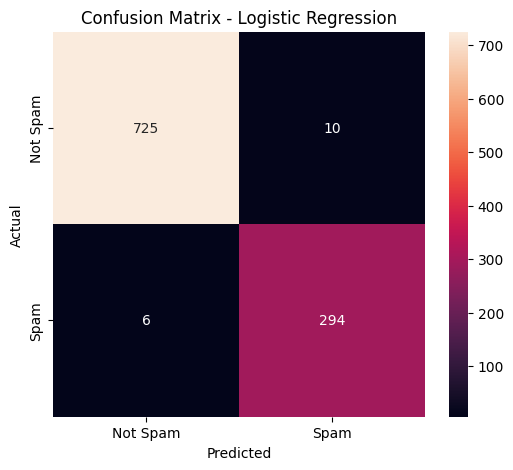

In [37]:
lr_cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt='d',
    xticklabels=['Not Spam', 'Spam'],
    yticklabels=['Not Spam', 'Spam']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')

plt.show()

In [38]:
def predict_spam_lr(message):
    cleaned = clean_text(message)
    message_tfidf = vectorizer.transform([cleaned])
    prediction = lr_model.predict(message_tfidf)[0]

    if prediction == 1:
        return "🚨 SPAM"
    else:
        return "✅ NOT SPAM"

In [39]:
print(predict_spam_lr(
    "Congratulations! You have won $1,000. Click here to claim your prize now!"
))

print(predict_spam_lr(
    "Hi, are we still meeting tomorrow at 5 pm? Please let me know."
))

🚨 SPAM
✅ NOT SPAM


## 11. Testing the Final Model

The final Logistic Regression model is tested on new email messages that were not part of the original dataset to demonstrate its practical spam-classification capability.

In [40]:
test_emails = [
    "URGENT! You have been selected to receive a $10,000 cash prize. Claim now!",
    "Hey, can you send me the notes from today's lecture?",
    "LIMITED TIME OFFER! Buy now and get 90% OFF!!!",
    "Reminder: Your appointment is scheduled for Monday at 10 AM.",
    "You have won a FREE vacation. Click this link to claim your reward!"
]

for email in test_emails:
    print("Email:", email)
    print("Prediction:", predict_spam_lr(email))
    print("-" * 70)

Email: URGENT! You have been selected to receive a $10,000 cash prize. Claim now!
Prediction: 🚨 SPAM
----------------------------------------------------------------------
Email: Hey, can you send me the notes from today's lecture?
Prediction: ✅ NOT SPAM
----------------------------------------------------------------------
Email: LIMITED TIME OFFER! Buy now and get 90% OFF!!!
Prediction: 🚨 SPAM
----------------------------------------------------------------------
Email: Reminder: Your appointment is scheduled for Monday at 10 AM.
Prediction: ✅ NOT SPAM
----------------------------------------------------------------------
Email: You have won a FREE vacation. Click this link to claim your reward!
Prediction: 🚨 SPAM
----------------------------------------------------------------------


# 12. Conclusion

This project developed a machine learning-based email spam classification system using a labeled Kaggle dataset.

The email text was first preprocessed to remove unnecessary formatting and characters. TF-IDF was then used to convert the text into numerical features suitable for machine learning.

Three classification algorithms were evaluated: Multinomial Naive Bayes, Logistic Regression, and Linear SVM.

Among the three models, Logistic Regression achieved the best overall performance, with an accuracy of **98.45%**, precision of **96.71%**, recall of **98.00%**, and an F1-score of **97.35%**.

The results demonstrate that machine learning and text-based feature extraction can effectively identify spam emails. The final model was also tested on new example emails and successfully classified them as spam or not spam.